# Hantavirus network 
This code will create a network graph (Conversational Network) for bluesky data on the hantavirus 

---
### Import data and Libraries

In [1]:
#Import all required libraries
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import community as community_louvain

In [2]:
#Load the data
graph_df = pd.read_csv("combined_hantavirus_clean.csv")

#Fill Missing replying_to columns as ROOT
#This is missing for root posts (not a reply or comment)
graph_df["replying_to"] = graph_df["replying_to"].fillna("ROOT")

#Drop all null values and ensure data is in correct type
graph_df = graph_df.dropna(subset=["author", "replying_to", "depth"])
graph_df = graph_df.astype({"author": str, "replying_to": str, "depth": int})

In [3]:
#View the data to ensure it has been correctly imported
graph_df

,uri,author,replying_to,text,created_at,depth,likes,reposts
0,at://did:plc:jt7gzhduaswkv52mqq4phye6/app.bsky...,mrhappyonbsky.eurosky.social,dietagespresse.com,😂🤣 and so it begins ..........,2026-05-11T15:06:01.095Z,1,0,0
1,at://did:plc:rumwkx7xd3dcbsp3e4i3ptwh/app.bsky...,cyberbadboy.com,ROOT,Hantavirus is no joke 😂\n\nThat's why I've sta...,2026-05-11T14:24:49.316Z,0,1963,242
2,at://did:plc:xsxjfbeakywwtkml5q5lhcrc/app.bsky...,freecialis.bsky.social,cyberbadboy.com,holy privilege batman. most working class peop...,2026-05-11T15:20:48.286Z,1,106,1
3,at://did:plc:xhoys6noboked2gnfi27pxnt/app.bsky...,kloudkat.bsky.social,cyberbadboy.com,Downloading the Hentaivirus off KissAnime to t...,2026-05-11T15:23:52.102Z,1,2,0
4,at://did:plc:xcvngmugzz7owrg4pz4qzowt/app.bsky...,greavesoflass.bsky.social,cyberbadboy.com,I've started masking when I go out to a rat fe...,2026-05-11T14:54:06.021Z,1,41,0
...,...,...,...,...,...,...,...,...
8479,at://did:plc:cc5vrng7rf2zerek6xh7bhll/app.bsky...,njbbari3.bsky.social,melhathnofury.bsky.social,Only if he is infected… and had a decent virae...,2026-05-09T06:28:48.427Z,4,5,1
8480,at://did:plc:7m6olqbqf6upax5hjwfldyvd/app.bsky...,musictplove.bsky.social,thecovidinfoguy.bsky.social,Meanwhile the US keeps putting lives at risk. ...,2026-05-09T05:48:08.196Z,1,9,5
8481,at://did:plc:3bd6p7ah522kteulpx2zvxus/app.bsky...,charitychicken.bsky.social,thecovidinfoguy.bsky.social,"JFC, of course. 🤦‍♀️",2026-05-09T02:32:05.869Z,1,9,0
8482,at://did:plc:viflamzasnec2prd3b7y2yg5/app.bsky...,crof.bsky.social,ROOT,"Hantavirus, COVID, norovirus, legionnaires’: w...",2026-05-09T19:50:45.639Z,0,14,13


---
### Build directed & Weighted Graph

In [4]:
#Code adapted from wk8 lab
#Build mappings
id2author = dict(zip(graph_df["uri"], graph_df["author"]))

#Infer root post author from commentsreplies where depth == 0
thread2author = dict(graph_df[graph_df["depth"] == 0].groupby("uri")["author"].first())

#Count identifiable posts per author
post_counts = pd.Series(thread2author).value_counts().to_dict()


In [5]:
#Output the users with the most posts
post_counts

{'reuters.com': 15,
 'thev.bsky.social': 12,
 'nytimes.com': 12,
 'theguardian.com': 11,
 'apnews.com': 9,
 'thecovidinfoguy.bsky.social': 8,
 'cnn.com': 7,
 'chantzy.bsky.social': 7,
 'pbsnews.org': 6,
 'realtuckfrumper.bsky.social': 6,
 'plaguepoems.bsky.social': 6,
 'nbcnews.com': 5,
 'canadahealthwatch.ca': 5,
 'aljazeera.com': 5,
 'krutikakuppalli.bsky.social': 4,
 'who.int': 4,
 'datareport.bsky.social': 4,
 'davidbflower.bsky.social': 4,
 'bloomberg.com': 4,
 'covid19disease.bsky.social': 4,
 'mackayim.bsky.social': 4,
 'thebulwark.com': 3,
 'cwebbonline.com': 3,
 'gavinyamey.bsky.social': 3,
 'onestpress.onestnetwork.com': 3,
 'mjfree.bsky.social': 3,
 'saltybitchables.bsky.social': 3,
 'ylepidemiologist.bsky.social': 3,
 'cidrap.bsky.social': 3,
 'bladeofthes.bsky.social': 3,
 'nature.com': 3,
 'bbcnews-world-rss.bsky.social': 3,
 'aaronparnas.bsky.social': 3,
 'minibubbly.bsky.social': 3,
 'thedailyshow.com': 3,
 'meidastouch.com': 3,
 'billmccarthy.bsky.social': 2,
 'thegods

In [6]:
#Code adapted from wk8 lab
#Create a directed weighted graph
#Direction is who replied to who
#Weight is how many interactions of that direction
replyGraph = nx.DiGraph()

#Add user nodes with postNum
for user in graph_df["author"].unique():
    replyGraph.add_node(user,postNum=int(post_counts.get(user, 0)))

#Add directed weighted reply edges
for _, row in graph_df.iterrows():
    user = row["author"]
    parent_id = row["replying_to"]

    #Determine if post is original post
    #We do not want to include root posts as a reply to a root post
    if parent_id == 'ROOT':
        parent_user = user

    #Replies to post or another reply
    else:
        parent_user = parent_id

    #Add edge: user -> parent_user
    if parent_user and parent_user != user:
        if replyGraph.has_edge(user, parent_user):
            replyGraph[user][parent_user]["replyNum"] += 1
        else:
            replyGraph.add_edge(user, parent_user, replyNum=1)

#Check graph
print("Nodes:", replyGraph.number_of_nodes())
print("Edges:", replyGraph.number_of_edges())

#Save the graph to a file
nx.write_graphml(replyGraph, "HV_reply_graph.graphml")

Nodes: 5478
Edges: 6845


---
### Centrality

In [23]:
#Code adapted from wk8 lab
sFileName = "HV_reply_graph.graphml"

#Reading file back in
replyGraph = nx.readwrite.read_graphml(sFileName)

#Computing the degree centrality and plotting it
lDegCentrality = nx.degree_centrality(replyGraph)

#Computing the Eigenvector centrality and plotting it
lEigenVectorCentrality = nx.eigenvector_centrality(replyGraph, max_iter=5000)

#Computing the Katz centrality and plotting it
lKatzCentrality = nx.katz_centrality(replyGraph, alpha=0.01, max_iter=5000)

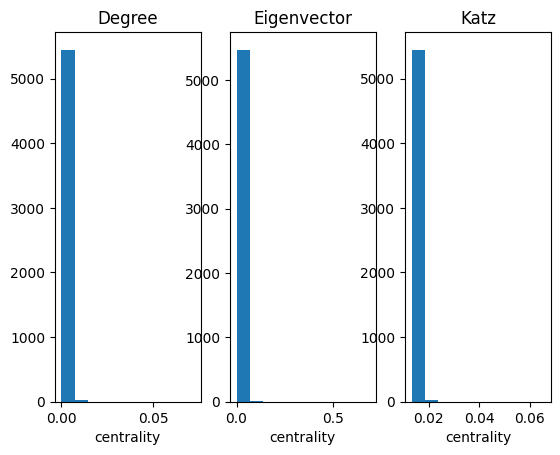

In [25]:
#Code adapted from wk8 lab
#Plot histograms for centrality measures
#Degree centrality
plt.subplot(1,3,1)
plt.hist(list(lDegCentrality.values()))
plt.title('Degree')
plt.xlabel('centrality')
#Eigenvector centrality
plt.subplot(1, 3, 2)
plt.hist(list(lEigenVectorCentrality.values()))
plt.title('Eigenvector')
plt.xlabel('centrality')
#Katz centrality
plt.subplot(1, 3, 3)
plt.hist(list(lKatzCentrality.values()))
plt.title('Katz')
plt.xlabel('centrality')

plt.show()

In [27]:
#Code adapted from wk8 lab
#Update the node attributes with centrality
#Eigenvector centrality, stored in node attribute 'eigen'
for nodeId, cent in lEigenVectorCentrality.items():
    replyGraph.nodes[nodeId]['eigen'] = float(cent)

#Katz centrality, stored in node attribute 'katz'
for nodeId, cent in lKatzCentrality.items():
    replyGraph.nodes[nodeId]['katz'] = float(cent)
    
#Write out graph to new file 
nx.readwrite.write_graphml(replyGraph, 'mod' + sFileName, infer_numeric_types=True)

#Compute and print clustering coefficient 
print('Gloabl clustering coefficient/transitivit = {}'.format(nx.transitivity(replyGraph)))

#Compute and print components (weak and strong)
print('number of strongly connected components = {}'.format(nx.number_strongly_connected_components(replyGraph)))
print('number of weakly connected components = {}'.format(nx.number_weakly_connected_components(replyGraph)))

#Compute and print bridges
print(list(nx.bridges(replyGraph.to_undirected())))

Gloabl clustering coefficient/transitivit = 0.021920233260439445
number of strongly connected components = 4838
number of weakly connected components = 249
[('mrhappyonbsky.eurosky.social', 'dietagespresse.com'), ('cyberbadboy.com', 'freecialis.bsky.social'), ('cyberbadboy.com', 'kloudkat.bsky.social'), ('cyberbadboy.com', 'greavesoflass.bsky.social'), ('cyberbadboy.com', 'monstersnowgoon.bsky.social'), ('cyberbadboy.com', 'jasonthee.bsky.social'), ('cyberbadboy.com', 'c2snow.bsky.social'), ('cyberbadboy.com', 'bflmouse.bsky.social'), ('cyberbadboy.com', 'halibut.bsky.social'), ('cyberbadboy.com', 'joodburn.bsky.social'), ('cyberbadboy.com', 'possumacquainter.bsky.social'), ('cyberbadboy.com', 'stewieeee.bsky.social'), ('cyberbadboy.com', 'saturnvf1.bsky.social'), ('cyberbadboy.com', 'rowzat.bsky.social'), ('cyberbadboy.com', 'warybear.bsky.social'), ('cyberbadboy.com', 'suannelqr.bsky.social'), ('cyberbadboy.com', 'crab.institute'), ('cyberbadboy.com', 'mnguy23.bsky.social'), ('cyberb

In [29]:
#Get the top 10 most central nodes (Eigenvector)
sortedEigen = sorted(lEigenVectorCentrality.items(), key=lambda x: x[1], reverse=True)
print(sortedEigen[:10])

[('raykwong.lol', 0.6902128520432677), ('trdowden2.bsky.social', 0.07659184095866796), ('merri24.bsky.social', 0.07523228674102085), ('thegopisfubar2024.bsky.social', 0.07508589098087869), ('dragonlady1011.bsky.social', 0.07508438684703375), ('bethtoja.bsky.social', 0.07508422321572174), ('sandiwi.bsky.social', 0.07508422321572174), ('inezsneks2024.bsky.social', 0.074360792553982), ('anonleeks.bsky.social', 0.06908357234183146), ('politicshealth.bsky.social', 0.06844184068961874)]


In [31]:
#Get the top 10 most central nodes (Katz)
sortedKatz = sorted(lKatzCentrality.items(), key=lambda x: x[1], reverse=True)
print(sortedKatz[:10])

[('cwebbonline.com', 0.06571496236359237), ('meidastouch.com', 0.06372916826639498), ('acyn.bsky.social', 0.047708691122196945), ('atrupar.com', 0.04415410050160769), ('thegodshow.com', 0.03747555202577947), ('muellershewrote.com', 0.03689277073412999), ('briantylercohen.bsky.social', 0.03550638836448305), ('raykwong.lol', 0.031391239908770754), ('kylegriffin1.bsky.social', 0.029953382190479876), ('thev.bsky.social', 0.02750035323964871)]


---
### Community detection in graphs

In [41]:
#Code adapted from wk9 lab
#Detect communities in graphs
#Read the updated graph with centrality
G = nx.read_graphml("modHV_reply_graph.graphml")

#Louvain
partition = community_louvain.best_partition(G.to_undirected())
for node, comm_id in partition.items():
    G.nodes[node]["louvain"] = comm_id

#CPM
k = 3
cpm_comms = list(nx.algorithms.community.k_clique_communities(G.to_undirected(), k))
for i, comm in enumerate(cpm_comms):
    for node in comm:
        G.nodes[node]["cpm"] = i

#Write to a new graph
nx.write_graphml(G, "HV_communities.graphml")